In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score,classification_report, confusion_matrix, accuracy_score

In [2]:
df = pd.read_csv("mushrooms.csv")
#target encoding
df["class"] = df["class"].map({"e": 0, "p": 1})

#one hot encoding for categorical features
X = pd.get_dummies(df.drop(columns=["class"]))
y = df["class"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling features (standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   
X_test_scaled = scaler.transform(X_test)   

In [11]:
iteration_values = list(range(1000, 100001, 2000))   #step 2,000
train_f1_iter = []
test_f1_iter = []

for n_iter in iteration_values:
    model = LogisticRegression(max_iter=n_iter, random_state=42)
    model.fit(X_train_scaled, y_train)

    train_f1_iter.append(f1_score(y_train, model.predict(X_train_scaled)))
    test_f1_iter.append(f1_score(y_test, model.predict(X_test_scaled)))

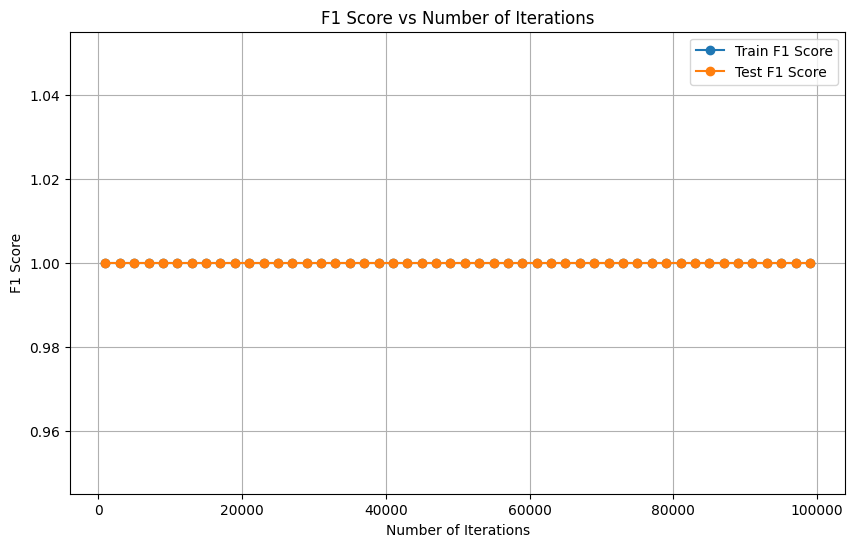

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(iteration_values, train_f1_iter, label='Train F1 Score', marker='o')
plt.plot(iteration_values, test_f1_iter, label='Test F1 Score', marker='o')
plt.title('F1 Score vs Number of Iterations')
plt.xlabel('Number of Iterations')
plt.ylabel('F1 Score')
plt.legend()
plt.grid()
plt.show()

In [15]:
best_index = test_f1_iter.index(max(test_f1_iter))

best_lr = iteration_values[best_index]
best_score = test_f1_iter[best_index]

print("Best Learning Rate:", best_lr)
print("Best Test F1:", best_score)

Best Learning Rate: 1000
Best Test F1: 1.0
